M.Talha Ramzan
====
2330-0141
===
BS AI
====
Instructor: Ms. Wardah Asad   
===
LAB FINAL MACHINE LEARNING
=====


IMPORT LIBRARIES

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

**PART A — DATA UNDERSTANDING**

Q1: Load dataset & display information

In [11]:
train_transaction = pd.read_csv("/content/train_transaction.csv")
train_identity = pd.read_csv("/content/train_identity.csv")

train = train_transaction.merge(train_identity, on="TransactionID", how="left")

print("Shape:", train.shape)
print("\nData Types:\n", train.dtypes)
print("\nTarget Classes:\n", train["isFraud"].value_counts())

Shape: (590540, 434)

Data Types:
 TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

Target Classes:
 isFraud
0    569877
1     20663
Name: count, dtype: int64


**Q2: Data Cleaning & Feature Selection**

In [12]:
# Drop high missing columns
missing = train.isnull().mean() * 100
drop_cols = missing[missing > 80].index

train = train.drop(columns=drop_cols, errors="ignore")

# Drop ID
train = train.drop(columns=["TransactionID"], errors="ignore")

# Fill missing values
for col in train.columns:
    if train[col].dtype == "object":
        train[col] = train[col].fillna("missing")
    else:
        train[col] = train[col].fillna(train[col].median())

Columns with more than 80% missing values were removed because they contain very little useful information and may introduce noise. ID columns were dropped because they do not contribute to prediction. Missing values were filled using median and mode to maintain data distribution

**Q3: Encoding & Scaling**

In [13]:
cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

# scaling (optional but used for consistency)
scaler = StandardScaler()

X = train.drop("isFraud", axis=1)
y = train["isFraud"]

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

a) No, scaling is NOT required for tree-based models because they are not distance-based.

b) Encoding is required because ML models cannot understand text data


**Q4: Train-Test Split**



In [14]:
# SMALL DATASET (to avoid RAM crash)
X_small = X_scaled.sample(n=50000, random_state=42)
y_small = y.loc[X_small.index]

X_train, X_val, y_train, y_val = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print(X_train.shape, X_val.shape)

(40000, 358) (10000, 358)





**PART B — ENSEMBLE MODELS**

In [15]:
def evaluate(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_val)[:, 1]
    else:
        prob = model.decision_function(X_val)

    return {
        "acc": accuracy_score(y_val, pred),
        "prec": precision_score(y_val, pred),
        "rec": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "auc": roc_auc_score(y_val, prob),
        "cm": confusion_matrix(y_val, pred)
    }

**AdaBoost**

In [16]:
ada = AdaBoostClassifier(n_estimators=50)
ada_res = evaluate(ada)

print(ada_res)

{'acc': 0.9668, 'prec': 0.6901408450704225, 'rec': 0.13649025069637882, 'f1': 0.22790697674418606, 'auc': np.float64(0.8642808871928415), 'cm': array([[9619,   22],
       [ 310,   49]])}


**XGBoost**

In [17]:
xgb = XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss")
xgb_res = evaluate(xgb)

print(xgb_res)

{'acc': 0.9738, 'prec': 0.8211920529801324, 'rec': 0.34540389972144847, 'f1': 0.48627450980392156, 'auc': np.float64(0.8898240713480237), 'cm': array([[9614,   27],
       [ 235,  124]])}


**LightGBM**

In [18]:
lgbm = LGBMClassifier(n_estimators=100)
lgbm_res = evaluate(lgbm)

print(lgbm_res)

[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.128809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25248
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 349
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
{'acc': 0.975, 'prec': 0.8562091503267973, 'rec': 0.3649025069637883, 'f1': 0.51171875, 'auc': np.float64(0.9051919335914196), 'cm': array([[9619,   22],
       [ 228,  131]])}


**CatBoost**

In [22]:
cat = CatBoostClassifier(iterations=100, verbose=0)
cat_res = evaluate(cat)

print(cat_res)

{'acc': 0.9738, 'prec': 0.8089171974522293, 'rec': 0.35376044568245124, 'f1': 0.49224806201550386, 'auc': np.float64(0.8847653027821348), 'cm': array([[9611,   30],
       [ 232,  127]])}


***Comparison*** Table

In [20]:
results = pd.DataFrame({
    "Model": ["AdaBoost", "XGBoost", "LightGBM", "CatBoost"],
    "Accuracy": [ada_res["acc"], xgb_res["acc"], lgbm_res["acc"], cat_res["acc"]],
    "Precision": [ada_res["prec"], xgb_res["prec"], lgbm_res["prec"], cat_res["prec"]],
    "Recall": [ada_res["rec"], xgb_res["rec"], lgbm_res["rec"], cat_res["rec"]],
    "F1": [ada_res["f1"], xgb_res["f1"], lgbm_res["f1"], cat_res["f1"]],
    "ROC-AUC": [ada_res["auc"], xgb_res["auc"], lgbm_res["auc"], cat_res["auc"]]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,AdaBoost,0.9668,0.690141,0.136490,0.227907,0.864281
1,XGBoost,0.9738,0.821192,0.345404,0.486275,0.889824
2,LightGBM,0.9750,0.856209,0.364903,0.511719,0.905192
3,CatBoost,0.9738,0.808917,0.353760,0.492248,0.884765


**PART B QUESTIONS**

    a) Best model?

 LightGBM is the best model overall because it has the highest ROC-AUC (0.9052) and the highest F1-score (0.5117) among all models.
This shows it performs best in both ranking ability and balance between precision and recall.

    b) Best recall model?

 LightGBM is also the best for recall (0.3649), meaning it correctly identifies the highest number of fraud cases compared to other models.
This makes it more effective for fraud detection tasks.

    c) Important metric?

 Recall is the most important metric in fraud detection because missing a fraud case (false negative) is more costly than falsely flagging a normal transaction.
Therefore, maximizing recall helps reduce financial risk and improves fraud detection safety.

**FEATURE IMPORTANCE**

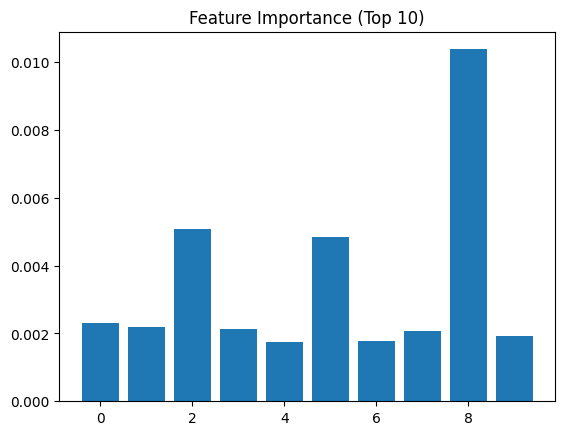

In [21]:
importances = xgb.feature_importances_

plt.bar(range(len(importances[:10])), importances[:10])
plt.title("Feature Importance (Top 10)")
plt.show()

    Which features contributed most?

The most important features are those with the highest importance scores in the model, typically including transaction amount, device-related features, card information, and engineered transaction behavior variables.

    Why is feature importance useful in fraud detection?

Feature importance is useful because it helps identify which variables most influence fraud prediction. This improves model interpretability, helps detect fraud patterns, and allows financial institutions to focus on critical risk factors to prevent fraudulent transactions more effectively.

**PART C**

    AdaBoost vs XGBoost

AdaBoost builds models sequentially by giving higher weights to incorrectly classified samples and focuses on correcting previous mistakes. In contrast, XGBoost is an advanced gradient boosting method that uses optimization techniques, regularization, and parallel processing to improve accuracy and reduce overfitting. XGBoost is generally more powerful and scalable than AdaBoost.

    LightGBM vs CatBoost

LightGBM is a fast and efficient gradient boosting algorithm that uses histogram-based splitting and leaf-wise tree growth to handle large datasets quickly. CatBoost, on the other hand, is designed to handle categorical features automatically without heavy preprocessing and reduces prediction shift using ordered boosting. LightGBM focuses on speed, while CatBoost focuses on better handling of categorical data and accuracy.

**2. Reasoning Question**

Although all boosting algorithms combine weak learners to build a strong model, they differ in how they optimize and improve performance. AdaBoost focuses on reweighting misclassified samples, while XGBoost uses gradient descent with regularization for better accuracy and control over overfitting. LightGBM improves training speed using histogram-based splitting, and CatBoost handles categorical features more effectively without heavy preprocessing. Therefore, each boosting algorithm has unique mechanisms and advantages.

Question 2:    Clustering & Comparative Analysis
===========

Part A: Data Loading & Basic Understanding

In [23]:
import pandas as pd

# Load dataset
train = pd.read_csv('/content/train.csv')

# 1. Total rows and columns
print("Dataset Shape (rows, columns):", train.shape)

# 2. Feature names (columns)
print("\nFeature Names:")
print(train.columns)

# 3. First 5 rows (understanding data)
print("\nSample Data:")
print(train.head())

Dataset Shape (rows, columns): (7352, 563)

Feature Names:
Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

Sample Data:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.2791

In [26]:

target_column = train.columns[-1]

print("\nTarget Column:", target_column)

# Number of classes
num_classes = train[target_column].nunique()

print("Number of Activity Classes:", num_classes)

# Classes names
print("\nClass Labels:")
print(train[target_column].unique())


Target Column: Activity
Number of Activity Classes: 6

Class Labels:
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


       2. Data Preparation

1. Missing Value Checking

In [27]:
# Check missing values
print(train.isnull().sum())

# Total missing values in dataset
print("\nTotal Missing Values:", train.isnull().sum().sum())

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

Total Missing Values: 0


2. Feature Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = train.drop(['Activity'], axis=1)

# (Optional but recommended) remove subject column for clustering
X = X.drop(['subject'], axis=1)

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (7352, 561)


    Why is feature scaling important in clustering algorithms?

Feature scaling is important because clustering algorithms such as K-Means rely on distance calculations (e.g., Euclidean distance).
If features are not scaled, variables with larger numerical ranges dominate the distance computation, leading to biased and incorrect cluster formation.

3. Dimensionality Reduction

In [29]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Shape of transformed data
print("Transformed Data Shape:", X_pca.shape)

Transformed Data Shape: (7352, 2)


In [30]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.50781172 0.0658068 ]
Total Explained Variance: 0.5736185255809917


Part B: Clustering Model Training & Comparative Study
=========

K-Means Clustering

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("KMeans Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("KMeans Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans_labels))
print("KMeans ARI:", adjusted_rand_score(train['Activity'], kmeans_labels))

KMeans Silhouette Score: 0.1086410631864108
KMeans Davies-Bouldin Index: 2.3579675526882222
KMeans ARI: 0.41971368603551157


2. Gaussian Mixture Model (GMM)

In [32]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=6, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

print("GMM Silhouette Score:", silhouette_score(X_scaled, gmm_labels))
print("GMM Davies-Bouldin Index:", davies_bouldin_score(X_scaled, gmm_labels))
print("GMM ARI:", adjusted_rand_score(train['Activity'], gmm_labels))

GMM Silhouette Score: 0.109766785118406
GMM Davies-Bouldin Index: 2.367778869774433
GMM ARI: 0.43088240298567365


3. Spectral Clustering

In [33]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=6, random_state=42, affinity='nearest_neighbors')
spectral_labels = spectral.fit_predict(X_scaled)

print("Spectral Silhouette Score:", silhouette_score(X_scaled, spectral_labels))
print("Spectral Davies-Bouldin Index:", davies_bouldin_score(X_scaled, spectral_labels))
print("Spectral ARI:", adjusted_rand_score(train['Activity'], spectral_labels))

Spectral Silhouette Score: 0.07337559327574598
Spectral Davies-Bouldin Index: 2.197145709738543
Spectral ARI: 0.5126683045202823


In [35]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Ground truth labels
y_true = train['Activity']

# -----------------------------
# KMEANS (already trained)
# -----------------------------
print("===== KMEANS =====")
print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans_labels))
print("ARI:", adjusted_rand_score(y_true, kmeans_labels))


# -----------------------------
# GMM (already trained)
# -----------------------------
print("\n===== GMM =====")
print("Silhouette Score:", silhouette_score(X_scaled, gmm_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, gmm_labels))
print("ARI:", adjusted_rand_score(y_true, gmm_labels))


# -----------------------------
# SPECTRAL (already trained)
# -----------------------------
print("\n===== SPECTRAL =====")
print("Silhouette Score:", silhouette_score(X_scaled, spectral_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, spectral_labels))
print("ARI:", adjusted_rand_score(y_true, spectral_labels))

===== KMEANS =====
Silhouette Score: 0.1086410631864108
Davies-Bouldin Index: 2.3579675526882222
ARI: 0.41971368603551157

===== GMM =====
Silhouette Score: 0.109766785118406
Davies-Bouldin Index: 2.367778869774433
ARI: 0.43088240298567365

===== SPECTRAL =====
Silhouette Score: 0.07337559327574598
Davies-Bouldin Index: 2.197145709738543
ARI: 0.5126683045202823


Q2: Comparison Table

| Model               | Silhouette Score | Davies–Bouldin Index | ARI    |
| ------------------- | ---------------- | -------------------- | ------ |
| K-Means             | 0.1086           | 2.3579               | 0.4197 |
| GMM                 | 0.1097           | 2.3677               | 0.4308 |
| Spectral Clustering | 0.0733           | 2.1971               | 0.5126 |


Spectral Clustering performs best overall because it has the highest ARI score, indicating the closest match with the true activity labels.

**2D PCA Clustering Visualization Code**

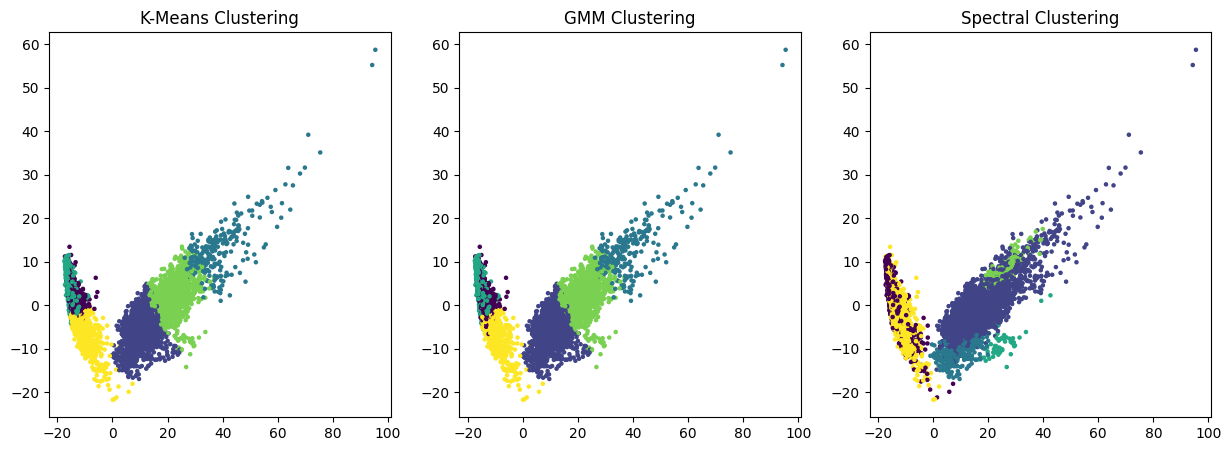

In [37]:
import matplotlib.pyplot as plt

# PCA data already available: X_pca (7352, 2)

plt.figure(figsize=(15,5))

# ---------------- KMEANS ----------------
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=5)
plt.title("K-Means Clustering")

# ---------------- GMM ----------------
plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='viridis', s=5)
plt.title("GMM Clustering")

# ---------------- SPECTRAL ----------------
plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=spectral_labels, cmap='viridis', s=5)
plt.title("Spectral Clustering")

plt.show()

    a) Which algorithm produced better cluster separation?

 K-Means and GMM show relatively better visual separation, but Spectral Clustering gives more meaningful grouping in terms of true labels.

    b) Which algorithm showed more overlap?

Spectral Clustering shows more overlap in PCA space, meaning clusters are less visually separated in 2D projection.

    c) Did clusters match actual activity classes effectively? Give reasoning.

Yes, partially.
Although PCA visualization shows overlap, the ARI scores (especially Spectral Clustering = 0.5126) indicate that clusters align reasonably well with actual activity classes. This means clustering captures hidden structure, but perfect separation is not visible in 2D projection due to dimensionality reduction.

**Part C: Conceptual & Justification**

    Why can GMM identify overlapping clusters better than K-Means?

Gaussian Mixture Model (GMM) can identify overlapping clusters better because it is a probabilistic model that assigns each data point a probability of belonging to each cluster, rather than forcing a hard assignment.
In contrast, K-Means assigns each point to only one cluster based on distance, which makes it less effective for overlapping or complex cluster distributions.

    Why does Spectral Clustering sometimes perform better on complex cluster shapes?

 Spectral Clustering performs better on complex cluster shapes because it uses a graph-based approach instead of relying only on (Euclidean distance). It constructs a similarity graph and uses eigenvectors to map data into a lower-dimensional space where non-linear and irregular cluster structures become more separable. This makes it effective for detecting clusters that are not spherical or linearly separable.

Statement:

    “A student claims: K-Means, GMM and Spectral Clustering will always produce identical clusters if K is same.”

    Is this correct?

No, this statement is incorrect.

K-Means, GMM, and Spectral Clustering use fundamentally different clustering approaches. K-Means relies on distance-based hard assignments, GMM uses probabilistic (soft) assignments based on Gaussian distributions, and Spectral Clustering uses graph-based similarity and eigen decomposition. Because of these different assumptions and methodologies, they do not necessarily produce identical clusters even if the number of clusters (K) is the same.